### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [71]:
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [39]:
df = pd.read_csv('./data/winequalityN.csv')

In [40]:
df.shape

(6497, 13)

In [41]:
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Step 3: Exploaring Data

#### Basic Info

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6487.0,7.216579,1.296750,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6489.0,0.339691,0.164649,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6494.0,0.318722,0.145265,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6495.0,5.444326,4.758125,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6495.0,0.056042,0.035036,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6488.0,3.218395,0.160748,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6493.0,0.531215,0.148814,0.22000,0.43000,0.51000,0.60000,2.00000


In [9]:
feature_info = pd.DataFrame(
    {'null': df.isnull().sum(), 'null(%)': round(100 * df.isnull().sum()/len(df), 2), 'unique': df.nunique(), 'type': df.dtypes}
)

In [10]:
feature_info

,null,null(%),unique,type
type,0,0.00,2,object
fixed acidity,10,0.15,106,float64
volatile acidity,8,0.12,187,float64
citric acid,3,0.05,89,float64
residual sugar,2,0.03,316,float64
chlorides,2,0.03,214,float64
free sulfur dioxide,0,0.00,135,float64
total sulfur dioxide,0,0.00,276,float64
density,0,0.00,998,float64
pH,9,0.14,108,float64


#### Target Distribution

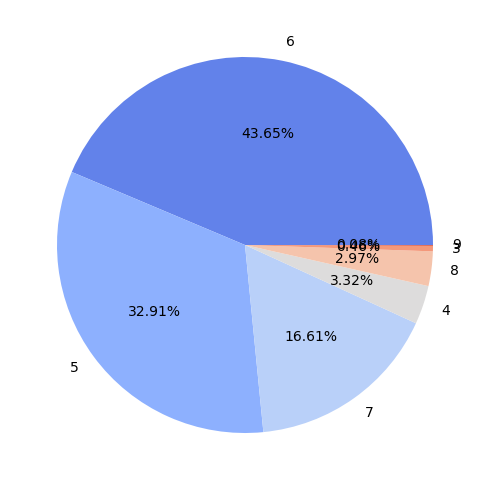

In [11]:
temp = df['quality'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index,
    colors=sns.color_palette('coolwarm', 7),
)
plt.tight_layout()

#### Object Distribution

In [15]:
obj_cols = df.select_dtypes(np.object_).columns.to_list()

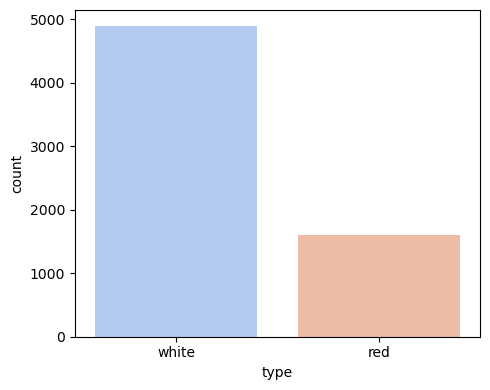

In [18]:
plt.figure(figsize=(5, 4))
for i, col in enumerate(obj_cols):
    plt.subplot(1, 1, i+1)
    sns.countplot(x=col, data=df, palette='coolwarm')
plt.tight_layout()

#### Float Distribution

In [13]:
float_cols = df.select_dtypes(np.float_).columns.to_list()

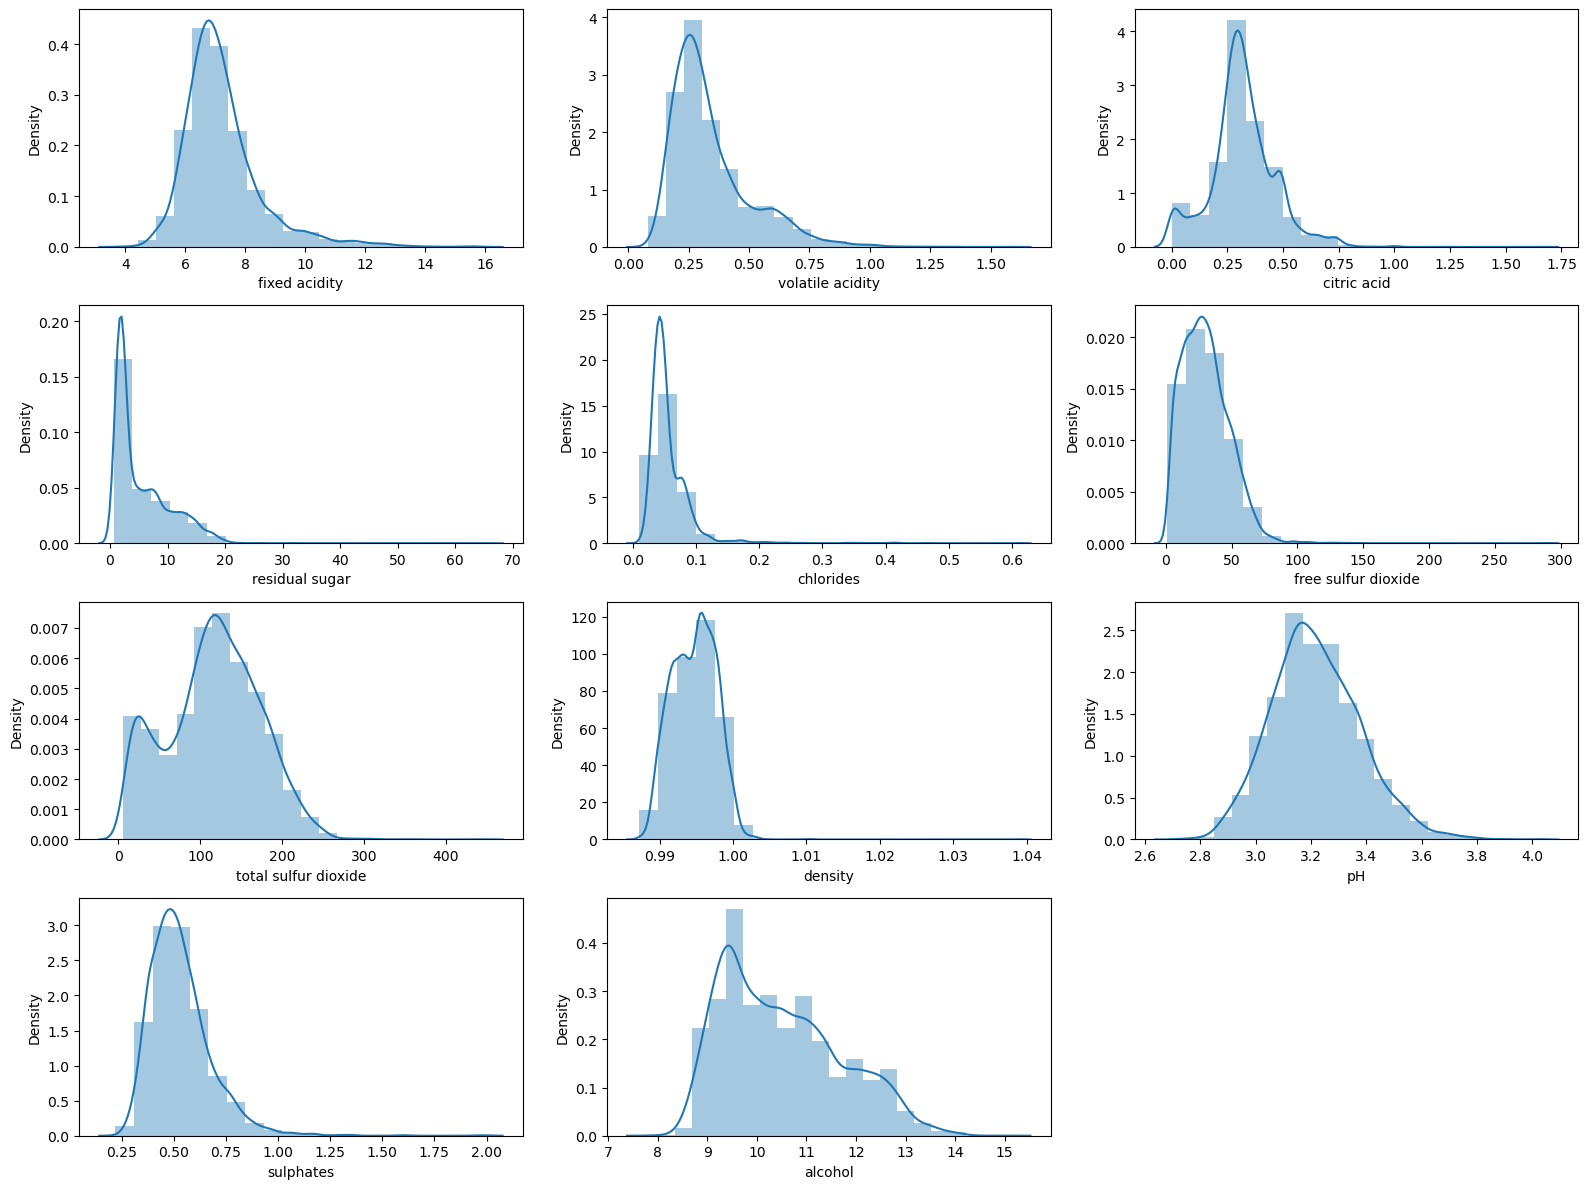

In [14]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(float_cols):
    plt.subplot(4, 3, i+1)
    sns.distplot(df[col], bins=20)
plt.tight_layout()

#### Other Distribution

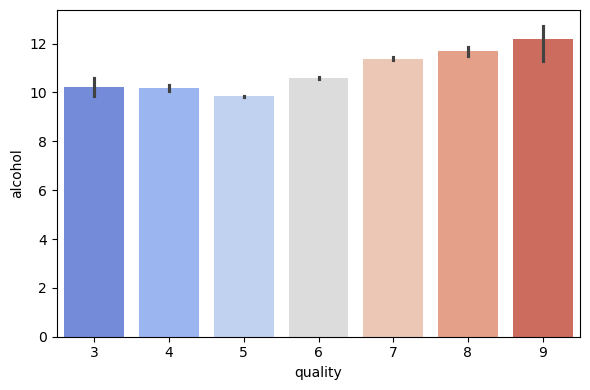

In [24]:
plt.figure(figsize=(6, 4))
sns.barplot(x='quality', y='alcohol', data=df, palette='coolwarm')
plt.tight_layout()

### Step 4: Feature Engineering

#### Handling Missing Value

In [42]:
null_cols = df.columns[df.isnull().any()].to_list()

In [43]:
for col in null_cols:
    df[col] = df[col].fillna(df[col].mean())

#### Feature Encoding

In [44]:
le = LabelEncoder()

In [45]:
df['type'] = le.fit_transform(df['type'])

#### Handling Target Label

In [46]:
df['best_quality'] = df['quality'].apply(lambda x: 1 if x > 5 else 0)

#### Heat Map

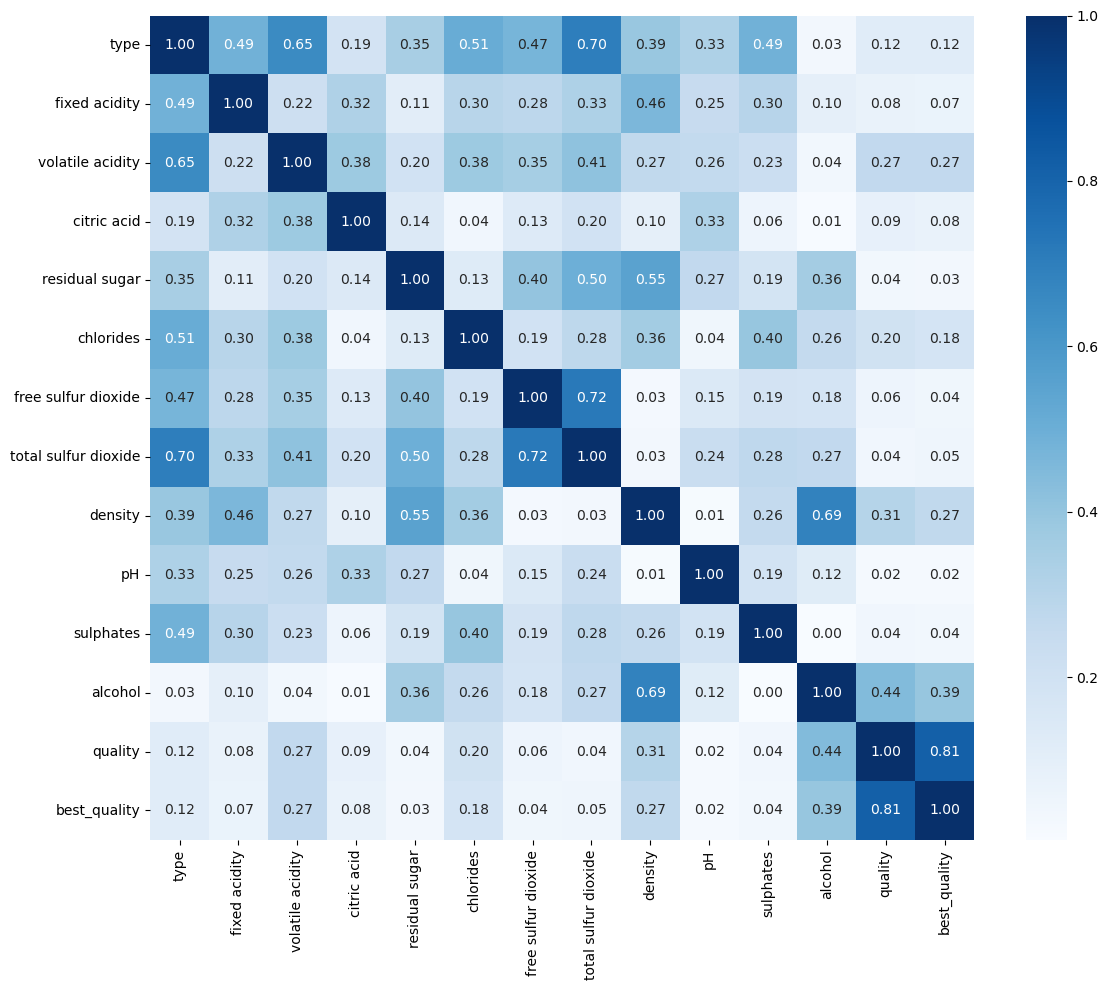

In [47]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [48]:
features = df.drop(['quality', 'best_quality'], axis=1)
target = df['best_quality']

In [54]:
selector = SmartCorrelatedSelection(threshold=0.7, selection_method='corr_with_target')

In [56]:
features = selector.fit_transform(features, target)

#### Split Data

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

#### Balance Data

In [65]:
ros = RandomOverSampler(sampling_strategy='minority', random_state=42)

In [66]:
X_train, y_train = ros.fit_resample(X_train, y_train)

#### Normalization

In [69]:
scaler = StandardScaler()

In [70]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

In [79]:
models = [
    LogisticRegression(),
    XGBClassifier(),
    SVC()
]

In [80]:
for model in models:
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        error_score='raise'
    )
    print(f'Model: {model.__class__.__name__}')
    print(f'Training Accuracy Scores: {[round(score, 3) for score in scores]}')
    print(f'Training Accuracy Mean Score: {round(scores.mean(), 3)}')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'Validation Accuracy Score: {round(metrics.roc_auc_score(y_test, y_pred), 3)}')
    print('-' * 20)

Model: LogisticRegression
Training Accuracy Scores: [0.79, 0.802, 0.794, 0.781, 0.803]
Training Accuracy Mean Score: 0.794
Validation Accuracy Score: 0.751
--------------------
Model: XGBClassifier
Training Accuracy Scores: [0.896, 0.911, 0.918, 0.954, 0.953]
Training Accuracy Mean Score: 0.926
Validation Accuracy Score: 0.805
--------------------
Model: SVC
Training Accuracy Scores: [0.83, 0.844, 0.833, 0.837, 0.845]
Training Accuracy Mean Score: 0.838
Validation Accuracy Score: 0.78
--------------------


In [81]:
cm = metrics.confusion_matrix(y_test, models[1].predict(X_test))

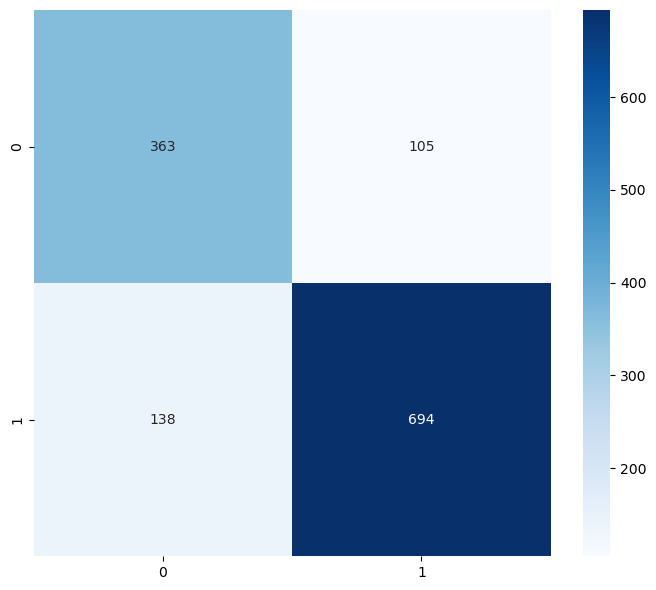

In [84]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    cmap=plt.cm.Blues,
    fmt='d',
    annot=True
)
plt.tight_layout()

In [85]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.81      0.72       468
           1       0.88      0.75      0.81       832

    accuracy                           0.77      1300
   macro avg       0.76      0.78      0.76      1300
weighted avg       0.79      0.77      0.78      1300

